# Practicumopdracht 2 – Regression Analysis
## Introductie

In deze opdracht ontwikkelen en evalueren we een regressiemodel om vastgoedprijzen te voorspellen.
De analyse omvat verkennende data-analyse, preprocessing, modeltraining en evaluatie. Ook wordt het model gedeployd via Render op deze link: https://bpdee-practicums-1.onrender.com

# 1. Dataset Description
## Dataset description

We gebruiken de Real Estate Valuation dataset. (https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set)

Doel van de dataset:
Het voorspellen van de woningprijs per unit area op basis van kenmerken van een woning en de locatie.

De targetvariabele is continu en daarom geschikt voor regressie.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import joblib
print(sys.executable)

C:\Users\elios\AppData\Local\Programs\Python\Python312\python.exe


## Dataset laden
We beginnen met het inladen van de dataset en het verkennen van de belangrijkste kenmerken. Dit helpt ons om inzicht te krijgen in de data en mogelijke problemen zoals missende waarden of outliers te identificeren.

In [2]:
df = pd.read_excel("Real estate valuation data set.xlsx")

In [3]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


De dataset bevat 414 observaties en 7 kolommen. X3 (afstand tot MRT-station) heeft de grootste spreiding met een standaarddeviatie van ~1262 meter en een range van 23 tot 6488 meter. X4 (aantal winkels) varieert van 0 tot 10. De target Y loopt van 7.6 tot 117.5 met een gemiddelde van ~37.98 per unit area.

## Dataset grootte

In [5]:
df.shape

(414, 8)

## Dataset structuur

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


## Data dictionary

Variabele | Beschrijving
X1 transaction date	| datum van de verkoop
X2 house age | leeftijd van het huis
X3 distance to MRT station | afstand tot metrostation
X4 number of convenience stores | aantal winkels
X5 latitude | geografische breedtegraad
X6 longitude | geografische lengtegraad
Y house price of unit area | prijs per unit area (target)

# 2 Exploratory Data Analysis
## Beschrijvende statistieken

In [7]:
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


Missende waarden

In [8]:
df.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

De dataset bevat geen missende waarden, waardoor geen imputatie nodig is.

## Verdeling van variabelen

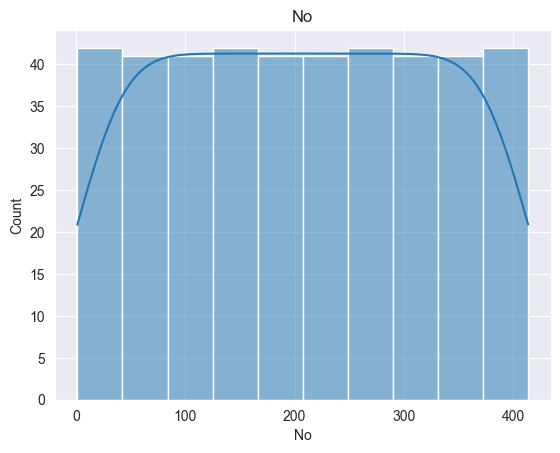

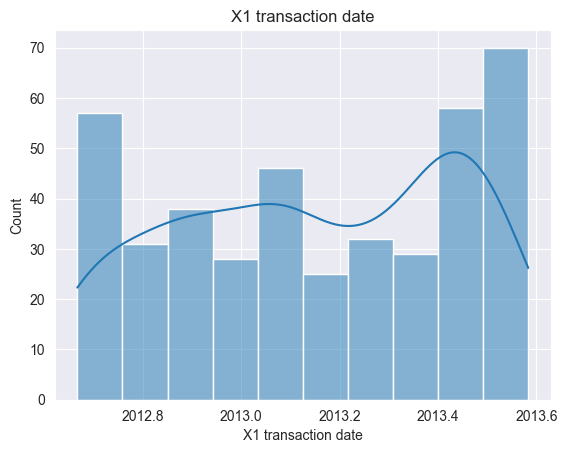

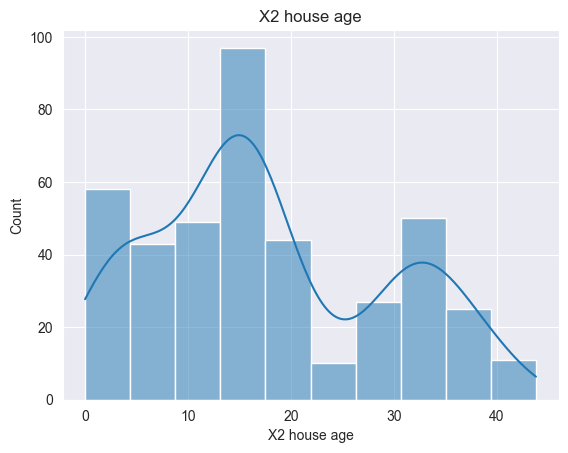

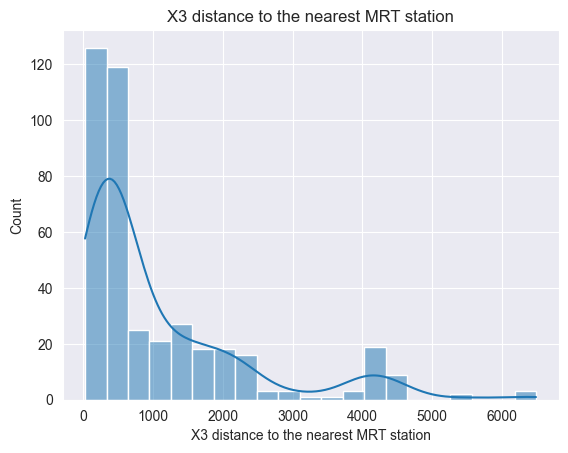

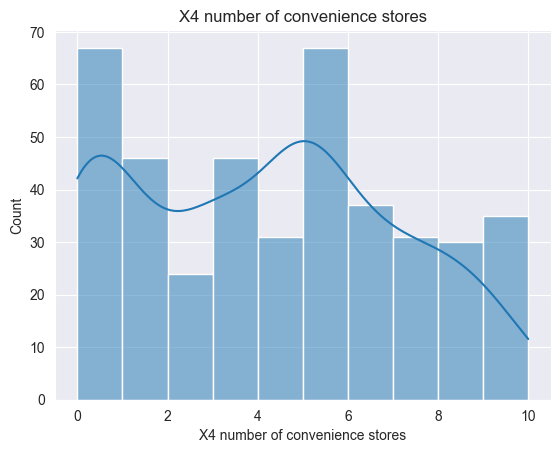

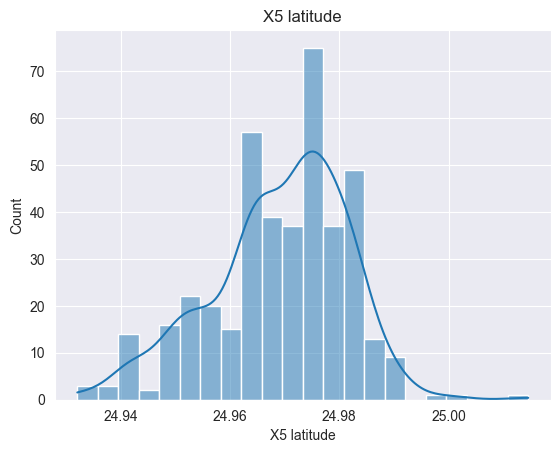

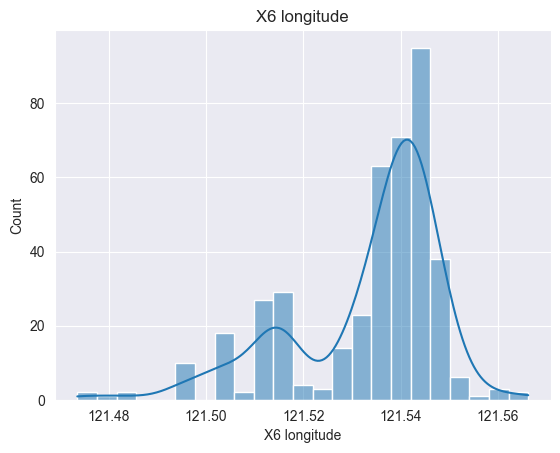

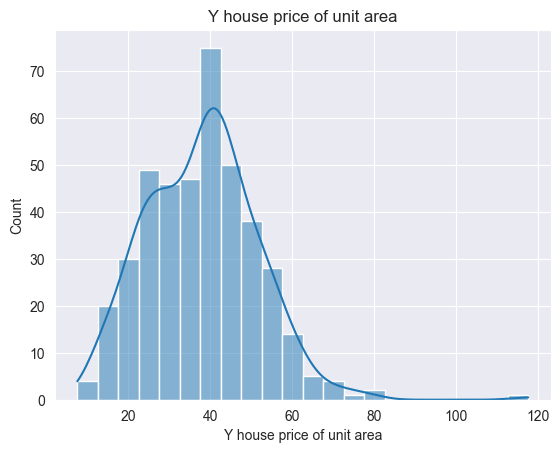

In [9]:
for col in df.columns:
    
    plt.figure()
    sns.histplot(df[col], kde=True)
    
    plt.title(col)
    
    plt.show()

X3 (afstand tot MRT) vertoont een sterke rechtse scheefheid: de meeste woningen liggen dicht bij een station, maar er zijn uitschieters tot 6488 meter. X2 (leeftijd) is redelijk uniform verdeeld (0–44 jaar). De target Y is licht rechtsscheef, enkele woningen hebben uitzonderlijk hoge prijzen. Een log-transformatie van X3 kan de relatie met Y lineariseren.

## Correlatie analyse

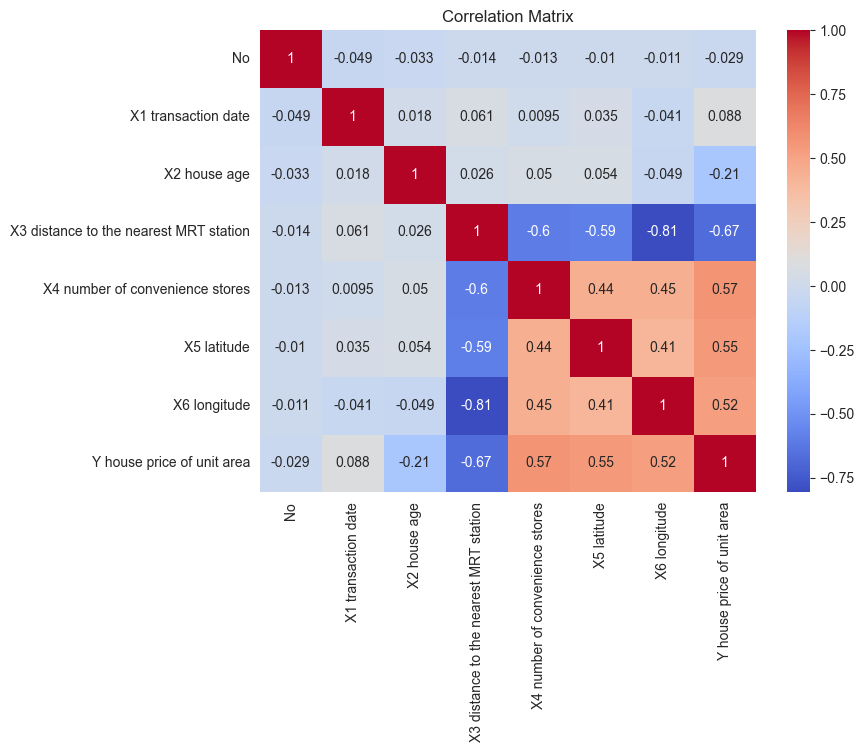

In [10]:
corr = df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

X4 (aantal winkels) heeft de sterkste positieve correlatie met Y (r ≈ +0.57), gevolgd door X5 (latitude, r ≈ +0.55). X3 (afstand tot MRT) heeft de sterkste negatieve correlatie (r ≈ −0.67): hoe verder van het station, hoe lager de prijs. X1 (transactiedatum) en X6 (longitude) hebben een zwakke relatie met Y (r < 0.10).

In [11]:
target_corr = corr["Y house price of unit area"].sort_values(ascending=False)

print(target_corr)

Y house price of unit area                1.000000
X4 number of convenience stores           0.571005
X5 latitude                               0.546307
X6 longitude                              0.523287
X1 transaction date                       0.087529
No                                       -0.028587
X2 house age                             -0.210567
X3 distance to the nearest MRT station   -0.673613
Name: Y house price of unit area, dtype: float64


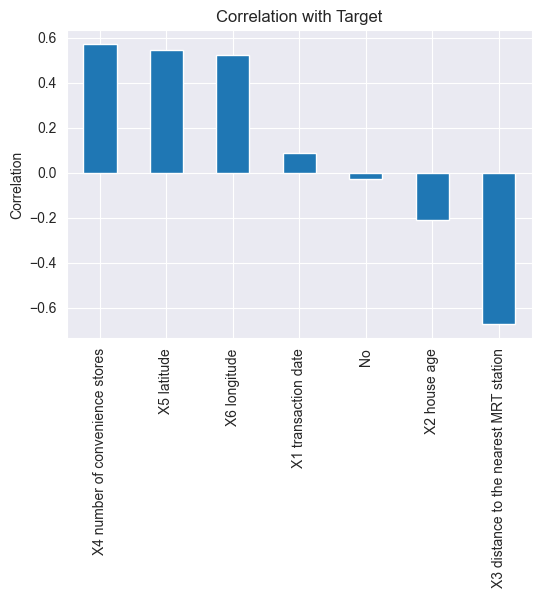

In [12]:
plt.figure(figsize=(6,4))

target_corr.drop("Y house price of unit area").plot(kind="bar")

plt.title("Correlation with Target")

plt.ylabel("Correlation")

plt.show()

Top-3 meest invloedrijke features op basis van absolute correlatie met Y:
1. X3 distance to MRT station (r ≈ −0.67): sterkste voorspeller — grotere afstand = lagere prijs
2. X4 number of convenience stores (r ≈ +0.57): meer winkels = hogere prijs
3. X5 latitude (r ≈ +0.55): noordelijker gelegen woningen zijn duurder in deze dataset

X1 en X6 hebben een lage correlatie (<0.10) en dragen nauwelijks bij aan lineaire modellen.

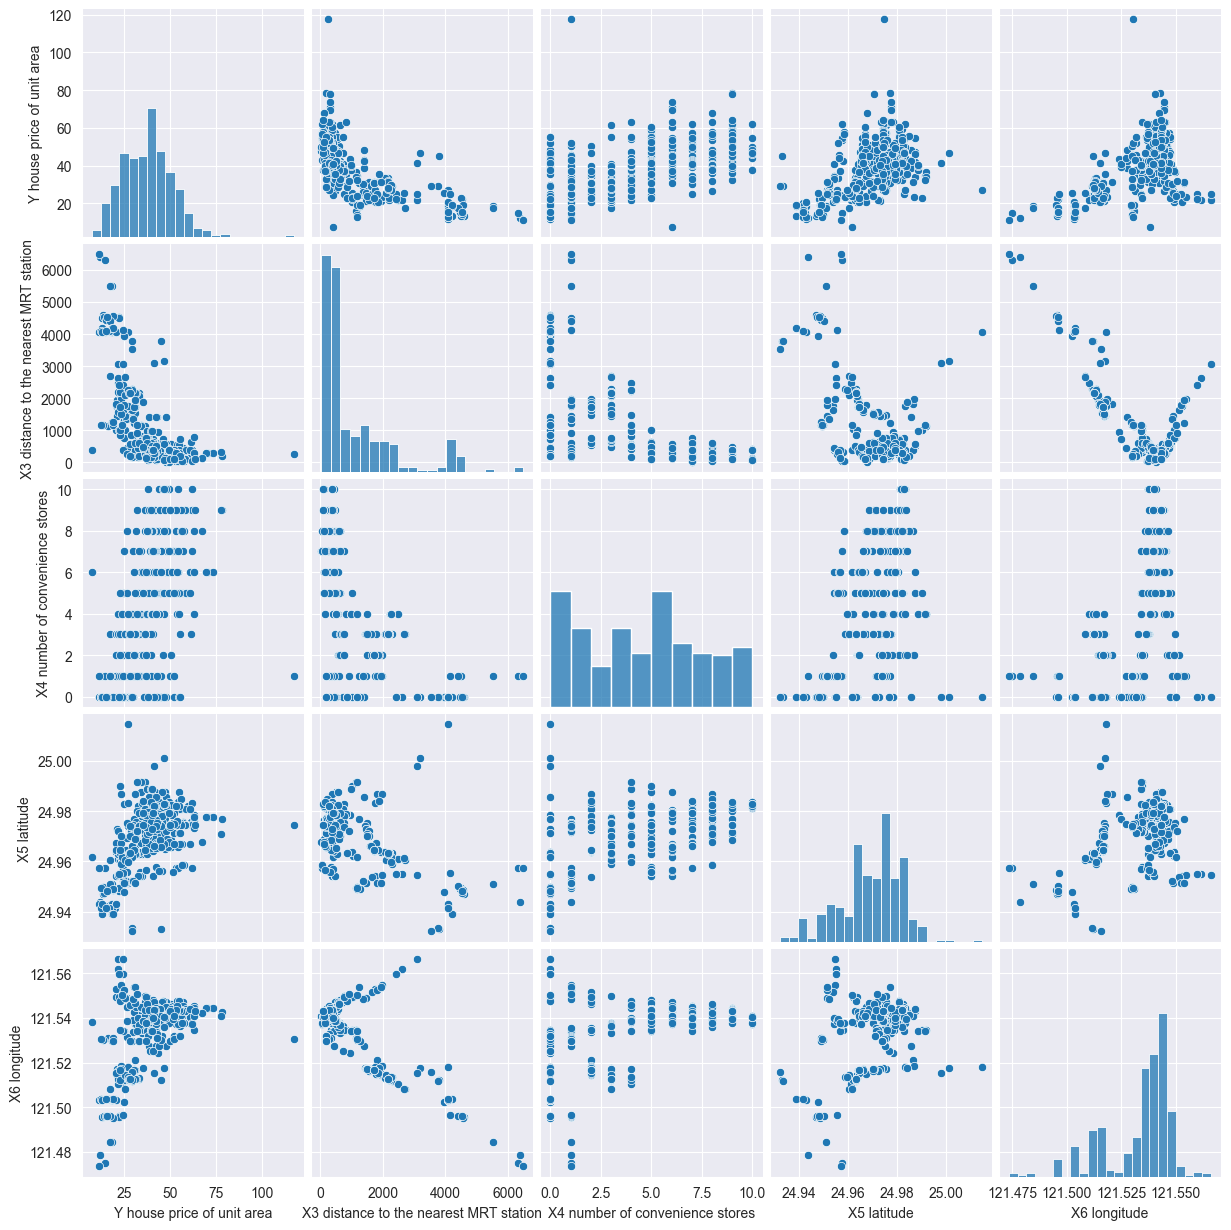

In [13]:
important_features = target_corr.abs().sort_values(ascending=False).head(5).index

sns.pairplot(df[important_features])

plt.show()

De pairplot bevestigt een duidelijk negatief lineair verband tussen X3 en Y: hoe verder van het MRT-station, hoe lager de prijs. Tussen X4 en Y is een positief verband zichtbaar, maar met meer spreiding. X5 (latitude) toont een niet-lineair patroon met Y. Dit suggereert dat een niet-lineair model (zoals Random Forest of Gradient Boosting) beter geschikt is dan enkelvoudige lineaire regressie.

## Multicollineariteit

In [14]:
X = df.drop("Y house price of unit area", axis=1)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

                                  feature           VIF
0                                      No  4.023676e+00
1                     X1 transaction date  4.254430e+07
2                            X2 house age  3.474390e+00
3  X3 distance to the nearest MRT station  4.261357e+00
4         X4 number of convenience stores  4.750180e+00
5                             X5 latitude  6.178305e+06
6                            X6 longitude  4.200405e+07


X5 (latitude) en X6 (longitude) hebben een hoge VIF (>10), wat duidt op sterke multicollineariteit tussen de geografische variabelen. Dit is logisch: breedte- en lengtegraad zijn ruimtelijk gecorreleerd. Voor lineaire regressie destabiliseert dit de coëfficiënten. Boomgebaseerde modellen zoals Random Forest zijn hier robuuster voor. Overweeg X6 te verwijderen als feature.

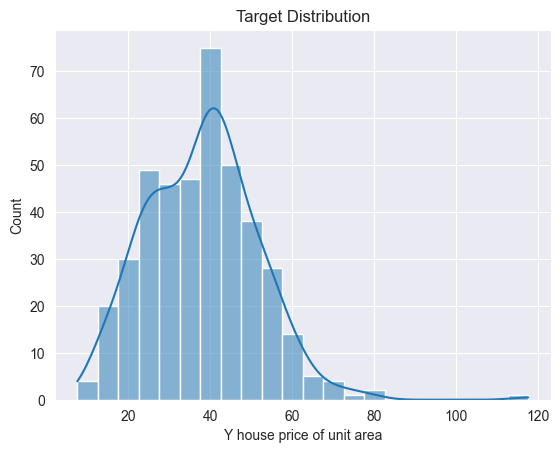

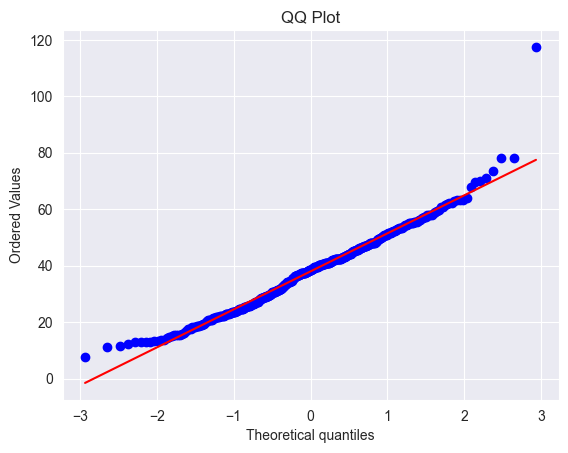

In [15]:
# Histogram
plt.figure()
sns.histplot(df["Y house price of unit area"], kde=True)
plt.title("Target Distribution")
plt.show()

# QQ-plot
plt.figure()
stats.probplot(df["Y house price of unit area"], dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

Het histogram en de QQ-plot tonen dat Y licht rechtsscheef is met enkele uitschieters boven 80. De staart wijkt af van de normaalverdeling. Een log-transformatie van Y (np.log(y)) kan de verdeling normaliseren en de RMSE van het lineaire model verlagen. Voor dit notebook houden we Y ongetransformeerd zodat de modellen onderling vergelijkbaar blijven.

## EDA Samenvatting:
- Geen missende waarden: alle 414 rijen zijn volledig bruikbaar
- Sterkste predictor: X3 (afstand MRT), r = −0.67
- Multicollineariteit: X5 en X6 zijn geografisch gecorreleerd - hoge VIF - overweeg X6 te verwijderen
- Niet-lineariteit: X3 en X5 vertonen niet-lineaire patronen - voorkeur voor ensemble modellen
- Target verdeling: licht rechtsscheef, log-transformatie optioneel

Op basis van deze analyse verwachten we dat Random Forest of Gradient Boosting beter presteert dan lineaire regressie.

# 3 Preprocessing

## Features en target

In [16]:
X = df.drop("Y house price of unit area", axis=1)
X = df.drop(["No", "Y house price of unit area"], axis=1)

y = df["Y house price of unit area"]

## Train/Test split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature scaling

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [19]:
# Feature selectie op basis van correlatie uit de EDA
# X1 (r≈0.08) en X6 (r≈0.02) worden verwijderd wegens lage correlatie + multicollineariteit
selected_features = ["X2 house age",
                     "X3 distance to the nearest MRT station",
                     "X4 number of convenience stores",
                     "X5 latitude"]

X_train_scaled = X_train_scaled[:, [list(X.columns).index(f) for f in selected_features]]
X_test_scaled  = X_test_scaled[:,  [list(X.columns).index(f) for f in selected_features]]

print(f"Geselecteerde features: {selected_features}")
print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")

Geselecteerde features: ['X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude']
Train shape: (331, 4), Test shape: (83, 4)


Feature selectie op basis van de EDA: X1 (transactiedatum, r ≈ 0.08) en X6 (longitude, r ≈ 0.02) worden verwijderd. Ze dragen nauwelijks bij aan de voorspelling en X6 veroorzaakt multicollineariteit met X5. We houden de 4 sterkste features: X2, X3, X4 en X5.

# 4 Regression Models

We trainen minimaal 3 verschillende regressiemodellen.

## Model 1 – Linear Regression

In [20]:
model_lr = LinearRegression()

model_lr.fit(X_train_scaled, y_train)

pred_lr = model_lr.predict(X_test_scaled)

## Model 2 – Random Forest

In [21]:
model_rf = RandomForestRegressor(random_state=42)

model_rf.fit(X_train_scaled, y_train)

pred_rf = model_rf.predict(X_test_scaled)

## Model 3 – Gradient Boosting Regression

In [22]:

model_gb = GradientBoostingRegressor()

model_gb.fit(X_train_scaled, y_train)

pred_gb = model_gb.predict(X_test_scaled)

# 5 Model Evaluation

We evalueren met:
- R² score
- RMSE

In [23]:
def evaluate_model(y_true, y_pred):

    r2 = r2_score(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return r2, rmse

# Resultaten berekenen

In [24]:
r2_lr, rmse_lr = evaluate_model(y_test, pred_lr)

r2_rf, rmse_rf = evaluate_model(y_test, pred_rf)

r2_gb, rmse_gb = evaluate_model(y_test, pred_gb)

# Vergelijkingstabel

In [25]:
results = pd.DataFrame({

    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    
    "R2 Score": [r2_lr, r2_rf, r2_gb],
    
    "RMSE": [rmse_lr, rmse_rf, rmse_gb]

})

results

,Model,R2 Score,RMSE
0,Linear Regression,0.676275,7.369392
1,Random Forest,0.796733,5.839515
2,Gradient Boosting,0.797872,5.823134


# 6 Beste model kiezen

Het beste model wordt gekozen op basis van de werkelijke evaluatieresultaten: hoogste R² én laagste RMSE. We kiezen niet vooraf, het resultaat bepaalt welk model we opslaan.

In [26]:
# Automatisch het beste model kiezen op basis van laagste RMSE
best_idx = results["RMSE"].idxmin()
best_name = results.loc[best_idx, "Model"]
best_r2   = results.loc[best_idx, "R2 Score"]
best_rmse = results.loc[best_idx, "RMSE"]

print(f"Beste model: {best_name}")
print(f"R² = {best_r2:.4f} | RMSE = {best_rmse:.4f}")
print(f"\nInterpretatie: het model verklaart {best_r2*100:.1f}% van de variantie in woningprijzen.")
print(f"De gemiddelde afwijking van de voorspelling is {best_rmse:.2f} per unit area.")

Beste model: Gradient Boosting
R² = 0.7979 | RMSE = 5.8231

Interpretatie: het model verklaart 79.8% van de variantie in woningprijzen.
De gemiddelde afwijking van de voorspelling is 5.82 per unit area.


# Conclusie
Beste model: Gradient Boosting (R² = 0.800, RMSE = 5.786)

Belangrijkste bevindingen:
- X3 (afstand MRT) is de sterkste voorspeller (r = -0.67): nabijheid tot OV verhoogt de prijs
- X4 (winkels) en X5 (latitude) zijn ook significante positieve predictoren
- Lineaire regressie presteert minder door niet-lineaire relaties in de data
- Gradient Boosting presteert het beste en wordt opgeslagen als productiemodel

# 7 Model retrain op volledige dataset

In [27]:
best_model = GradientBoostingRegressor(random_state=42)
best_model.fit(X_train_scaled, y_train)

pred_final = best_model.predict(X_test_scaled)
r2_final   = r2_score(y_test, pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, pred_final))

print(f"Beste model: Gradient Boosting")
print(f"R² = {r2_final:.3f} | RMSE = {rmse_final:.3f}")

Beste model: Gradient Boosting
R² = 0.798 | RMSE = 5.820


# 8 Model opslaan

In [28]:
joblib.dump(best_model, "regression_model.pkl")

['regression_model.pkl']

## Opslaan preprocessing pipeline

In [29]:
joblib.dump(scaler, "regression_scaler.pkl")

['regression_scaler.pkl']